#### Импорты

In [ ]:
!pip install transformers accelerate datasets adjustText

In [ ]:
import os
import re
import torch
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from time import time
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer
)

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from adjustText import adjust_text
import plotly.express as px

from nltk.corpus import stopwords
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import sent_tokenize

from datasets import Dataset
from google.colab import drive

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
BASE_MODEL = "answerdotai/ModernBERT-base"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model = AutoModel.from_pretrained("answerdotai/ModernBERT-base")

print("Модель и токенизатор загружены!")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель и токенизатор загружены!


#### Загрузка текста

In [ ]:
def load_and_clean_text(filepath):
    """Загружает текст и убирает маркеры глав."""
    with open(filepath, encoding="utf-8") as f:
        text = f.read()

    # Убирает "chapter" и его вариации
    text = re.sub(r'^\s*chapter\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)
    text = re.sub(r'^\s*chapter\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)

    return text

In [ ]:
def split_into_sentences(text):
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

In [ ]:
rebecca_text = load_and_clean_text("/content/drive/MyDrive/4 course/Rebecca.txt")
rebecca_sentences = split_into_sentences(rebecca_text)

print(f"Загружено {len(rebecca_sentences)} предложений")
print(f"Первое предложение: {rebecca_sentences[0][:100]}...\n")

Загружено 12614 предложений
Первое предложение: Last night I dreamt I went to Manderley again....



## Визуализация первых 500 предложений текста

In [ ]:
def get_embedding(text, model, tokenizer, var, device="cuda"):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.base_model(**inputs)

    if var == 1: # как эмбеддинг берется первый токен ([CLS])
        embedding = outputs.last_hidden_state[:, 0, :].squeeze(0).cpu()
    elif var == 2: # как эмбеддинг берется среднее из всех эмбеддингов в предложении
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()

    return embedding

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Используется: {device}")

Используется: cuda


In [ ]:
embeddings_1 = []
for sentence in rebecca_sentences[:500]:  # для начала первые 500
    emb = get_embedding(sentence, model, tokenizer, 1, device=device)
    embeddings_1.append(emb)

In [ ]:
embeddings_1[1]

tensor([ 1.0462e+00, -1.2716e+00, -1.6496e+00,  6.0931e-02, -7.0434e-01,
        -6.0109e-01, -1.0591e+00, -1.3883e+00,  5.4820e-01, -5.1072e-01,
        -1.1223e+00,  1.1088e+00, -1.5235e+00, -6.4816e-01, -3.7141e-01,
        -3.7327e-01, -3.8357e-01, -6.2651e-01,  2.7492e-01,  1.1157e+00,
         3.3112e-01, -6.8536e-01,  1.3019e-01,  9.6046e-01, -7.4407e-01,
        -2.1272e-01, -1.0189e+00,  2.0229e-01, -2.0081e-02,  9.6326e-01,
        -1.3329e+00, -9.4542e-01,  1.1697e-01, -2.4526e-01,  7.5830e-01,
         4.8004e-01, -1.0020e+00, -7.7677e-01, -4.9819e-01, -3.0284e-01,
        -2.0109e-01, -4.4097e-01,  5.7084e-01, -1.0576e+00,  3.9511e-01,
         5.3584e-01,  2.9036e-01, -9.8938e-01,  1.1119e-01,  7.3304e-02,
         1.6064e+00, -5.4531e-01, -2.7106e-01,  6.6174e-01,  2.3795e-01,
        -7.9803e-01, -5.0605e-01, -6.2413e-01, -8.9024e-01, -4.2122e-01,
         8.0600e-03,  2.7569e-01, -8.2416e-02,  2.6231e-01, -1.0777e-01,
        -1.4091e+00, -8.3635e-01,  2.3869e+01, -9.4

In [ ]:
embeddings_2 = []
for sentence in rebecca_sentences[:500]:
    emb = get_embedding(sentence, model, tokenizer, 2, device=device)
    embeddings_2.append(emb)

In [ ]:
embeddings_2[1]

array([-9.18522291e-03, -2.39815146e-01, -4.74048555e-01, -2.54618209e-02,
       -1.98012024e-01,  4.36206132e-01,  3.72583538e-01, -1.97203323e-01,
       -1.69382453e-01,  8.57188761e-01, -5.35916746e-01,  8.83639038e-01,
       -3.18991035e-01,  4.51835424e-01, -5.47953308e-01,  3.49472582e-01,
       -6.18778408e-01,  9.67414200e-01,  1.44661918e-01, -4.50441748e-01,
        3.75666283e-02,  2.69269049e-01, -1.63177788e-01, -4.74970937e-01,
       -3.83119196e-01,  7.96441019e-01,  3.30148011e-01, -1.15869641e-02,
        3.75108987e-01,  2.03631178e-01, -3.15831959e-01, -4.08469141e-01,
       -2.92614177e-02,  2.48889104e-01,  8.66619289e-01,  4.62330192e-01,
       -3.92665118e-01, -2.09263608e-01,  1.64332643e-01,  1.11075796e-01,
       -1.32800475e-01,  2.05239728e-01, -6.67319596e-01, -4.78545368e-01,
        4.91115510e-01, -1.04076006e-01, -2.47512460e-01,  1.05932772e+00,
       -1.48773313e-01,  1.43460006e-01,  2.56401151e-01,  2.30208114e-02,
        2.46234223e-01,  

In [ ]:
def visualisation(embeddings, name, method='tsne'):
    if method == 'tsne':
        embeddings = np.array(embeddings)
        perplexity = min(30, len(embeddings) - 1)
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
        embeddings_2d = tsne.fit_transform(embeddings)
    elif method == "pca":
        reducer = PCA(n_components=2)
        embeddings_2d = reducer.fit_transform(embeddings)
    else:
        raise ValueError(f"Неизвестный метод: {method}. Используй 'tsne' или 'pca'.")

    n_clusters = 8
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    df = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "cluster": labels.astype(str),
    "sentence": rebecca_sentences[:500]
    })

    method_name = "TSNE" if method == 'tsne' else 'PCA'

    fig = px.scatter(
        df,
        x='x', y='y',
        color='cluster',
        hover_data={"sentence": True, "x": False, "y": False},
        title=name + " c " + method_name,
        width=1000, height=700
    )

    fig.update_traces(marker=dict(size=6, opacity=0.7))
    fig.show()

In [ ]:
visualisation(embeddings_1, "t-SNE 'Ребекка' CLS")

In [ ]:
visualisation(embeddings_2, "t-SNE 'Ребекка' Mean pooling")

In [ ]:
visualisation(embeddings_1, "t-SNE 'Ребекка' CLS", 'pca')

In [ ]:
visualisation(embeddings_2, "t-SNE 'Ребекка' Mean pooling", 'pca')

## Дообученная модель

! часть кода отсутствует (нет обозначения и вызова дообученной модели)

Визуализация кластеризации первых 500 предложения с дообученной моделью ModernBERT v1 / ембеддинги по CLS

In [ ]:
def get_embedding(text, model, tokenizer, device="cuda"):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.base_model(**inputs)

    # Берём [CLS]-токен как эмбеддинг всего текста
    embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return embedding

In [ ]:
# Диагностика — запусти отдельно
test_inputs = tokenizer(
    "Test sentence.",
    return_tensors="pt",
    truncation=True,
    max_length=512,
    padding=True
)
print(test_inputs.keys())  # смотрим что там есть


dict_keys(['input_ids', 'attention_mask'])


In [ ]:
embeddings = []
for sentence in rebecca_sentences[:500]:  # для начала первые 500
    emb = get_embedding(sentence, model, tokenizer)
    embeddings.append(emb)

import numpy as np
embeddings = np.array(embeddings)
print(f"Shape: {embeddings.shape}")  # (500, 768)


W0318 13:52:19.824000 11899 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Shape: (500, 768)


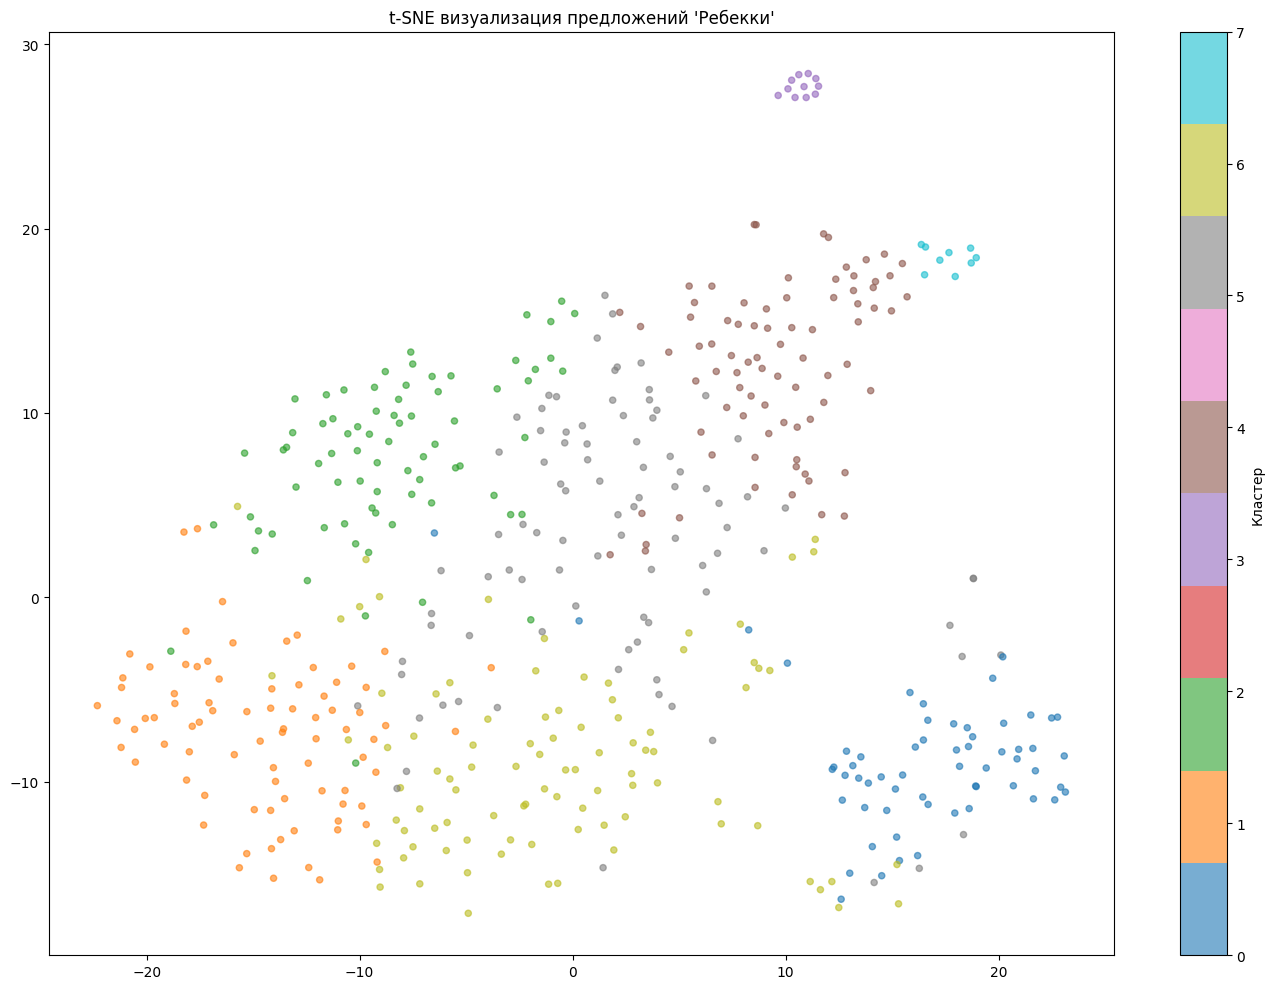

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from adjustText import adjust_text

# t-SNE — снижаем размерность 768 → 2
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# KMeans кластеризация
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

# Визуализация
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=labels, cmap="tab10", alpha=0.6, s=20
)
plt.colorbar(scatter, label="Кластер")
plt.title("t-SNE визуализация предложений 'Ребекки'")
plt.tight_layout()
# plt.savefig("/content/drive/MyDrive/rebecca_tsne.png", dpi=150)
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Готовим данные
df = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "cluster": labels.astype(str),
    "sentence": rebecca_sentences[:500]
})

# Интерактивный график
fig = px.scatter(
    df,
    x="x", y="y",
    color="cluster",
    hover_data={"sentence": True, "x": False, "y": False},
    title="t-SNE визуализация предложений 'Ребекки'",
    width=1000, height=700
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.show()
